In [1]:
import os
from pathlib import Path
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import getpass

# Workarounds for OpenMP + Matplotlib in non-interactive runs
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp/matplotlib")))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import act

print("✓ All packages imported successfully")


✓ All packages imported successfully


In [2]:
# Note - recommended ARM Live token to be set as an environmental variable
# e8ddc4f79e1c34a

# Check for env variables, otherwise set your username and token here!
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

# Set the datastream and start/enddates
los_datastream = 'sgpmwrlosC1.b1'
mfrs_datastream = 'sgpmfrsr7nchC1.b1'

startdate = '2025-01-01'
enddate = '2026-01-01'

# Use ACT to easily download the data.  Watch for the data citation!  Show some support
# for ARM's instrument experts and cite their data if you use it in a publication
result_los_met = act.discovery.download_arm_data(arm_username, arm_token, los_datastream, startdate, enddate)
result_mfrs_met = act.discovery.download_arm_data(arm_username, arm_token, mfrs_datastream, startdate, enddate)

Enter ARM username:  jcorner
Enter ARM token (hidden):  ········


[DOWNLOADING] sgpmwrlosC1.b1.20250101.000000.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250101.000040.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250102.000020.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250103.000000.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250104.000004.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250105.000000.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250106.000033.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250107.000007.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250108.000005.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250109.000016.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250110.000000.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250111.000005.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250112.000025.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250113.000016.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250114.000016.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250115.000013.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250116.000005.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250117.000001.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250118.000007.cdf
[DOWNLOADING] sgpmwrlosC1.b1.20250119.000037.cdf
[DOWNLOADING] sgpmwr

In [3]:
#load the datafiles into a single nc file. 
ds_los = act.io.read_arm_netcdf(result_los_met)
ds_mfrs = act.io.read_arm_netcdf(result_mfrs_met)

ds_mfrs

<xarray.Dataset> Size: 83GB
Dimensions:                                  (time: 1573879, bench_angle: 181,
                                              wavelength: 750)
Coordinates:
  * time                                     (time) datetime64[ns] 13MB 2025-...
  * bench_angle                              (bench_angle) float32 724B 0.0 ....
Dimensions without coordinates: wavelength
Data variables: (12/158)
    base_time                                (time) datetime64[ns] 13MB 2025-...
    time_offset                              (time) datetime64[ns] 13MB 2025-...
    hemisp_narrowband_filter1                (time) float32 6MB dask.array<chunksize=(4320,), meta=np.ndarray>
    qc_hemisp_narrowband_filter1             (time) int32 6MB dask.array<chunksize=(4320,), meta=np.ndarray>
    hemisp_narrowband_filter2                (time) float32 6MB dask.array<chunksize=(4320,), meta=np.ndarray>
    qc_hemisp_narrowband_filter2             (time) int32 6MB dask.array<chunksize=(4320,), meta=np.ndarray>
    ...                                       ...
    nominal_calibration_factor_filter5       (time) float32 6MB 196.7 ... 196.7
    nominal_calibration_factor_filter6       (time) float32 6MB 453.1 ... 453.1
    nominal_calibration_factor_filter7       (time) float32 6MB 30.0 ... 30.0
    lat                                      (time) float32 6MB 36.6 ... 36.6
    lon                                      (time) float32 6MB -97.49 ... -9...
    alt                                      (time) float32 6MB 318.0 ... 318.0
Attributes: (12/38)
    command_line:                mfrsr7nch_ingest -s sgp -f C1
    Conventions:                 ARM-1.2
    process_version:             ingest-mfrsr7nch-1.8-0.el7
    dod_version:                 mfrsr7nch-b1-1.1
    input_source:                /data/collection/sgp/sgpmfrsr7nchC1.00/MFRSR...
    site_id:                     sgp
    ...                          ...
    doi:                         10.5439/1429369
    history:                     created by user dsmgr on machine prod-proc3....
    _file_dates:                 ['20250101', '20250102', '20250103', '202501...
    _file_times:                 ['070000', '070000', '070000', '070000', '07...
    _datastream:                 sgpmfrsr7nchC1.b1
    _arm_standards_flag:         1

In [4]:
ds_los.to_netcdf('radiometer.nc')
ds_mfrs.to_netcdf('mfrs.nc')


KeyboardInterrupt



In [5]:
ds_mfrs

<xarray.Dataset> Size: 83GB
Dimensions:                                  (time: 1573879, bench_angle: 181,
                                              wavelength: 750)
Coordinates:
  * time                                     (time) datetime64[ns] 13MB 2025-...
  * bench_angle                              (bench_angle) float32 724B 0.0 ....
Dimensions without coordinates: wavelength
Data variables: (12/158)
    base_time                                (time) datetime64[ns] 13MB 2025-...
    time_offset                              (time) datetime64[ns] 13MB 2025-...
    hemisp_narrowband_filter1                (time) float32 6MB dask.array<chunksize=(4320,), meta=np.ndarray>
    qc_hemisp_narrowband_filter1             (time) int32 6MB dask.array<chunksize=(4320,), meta=np.ndarray>
    hemisp_narrowband_filter2                (time) float32 6MB dask.array<chunksize=(4320,), meta=np.ndarray>
    qc_hemisp_narrowband_filter2             (time) int32 6MB dask.array<chunksize=(4320,), meta=np.ndarray>
    ...                                       ...
    nominal_calibration_factor_filter5       (time) float32 6MB 196.7 ... 196.7
    nominal_calibration_factor_filter6       (time) float32 6MB 453.1 ... 453.1
    nominal_calibration_factor_filter7       (time) float32 6MB 30.0 ... 30.0
    lat                                      (time) float32 6MB 36.6 ... 36.6
    lon                                      (time) float32 6MB -97.49 ... -9...
    alt                                      (time) float32 6MB 318.0 ... 318.0
Attributes: (12/38)
    command_line:                mfrsr7nch_ingest -s sgp -f C1
    Conventions:                 ARM-1.2
    process_version:             ingest-mfrsr7nch-1.8-0.el7
    dod_version:                 mfrsr7nch-b1-1.1
    input_source:                /data/collection/sgp/sgpmfrsr7nchC1.00/MFRSR...
    site_id:                     sgp
    ...                          ...
    doi:                         10.5439/1429369
    history:                     created by user dsmgr on machine prod-proc3....
    _file_dates:                 ['20250101', '20250102', '20250103', '202501...
    _file_times:                 ['070000', '070000', '070000', '070000', '07...
    _datastream:                 sgpmfrsr7nchC1.b1
    _arm_standards_flag:         1

In [9]:
ds_mfrs[['direct_normal_narrowband_filter6', 'qc_direct_normal_narrowband_filter6']].to_netcdf('mfrs.nc')

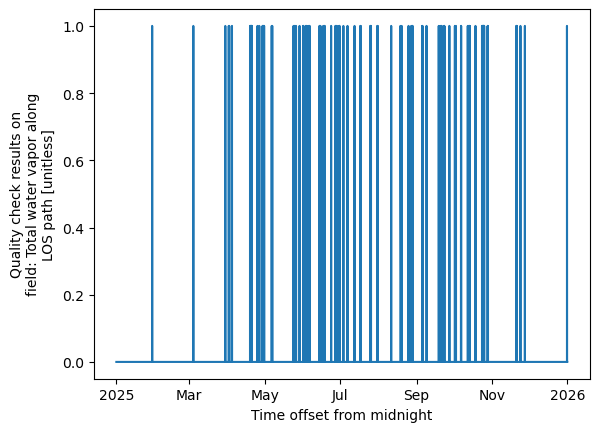

In [9]:
qc_vap_idx = np.where(ds_los['qc_vap'].values == 0)
qc_direct_idx = 

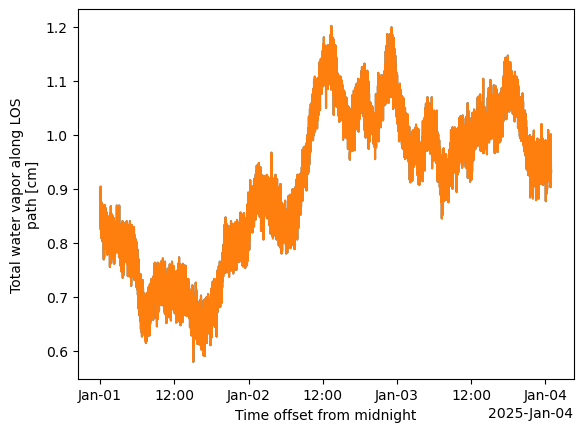

In [19]:
idx = np.where(ds_cf_met['qc_vap'].values == 0)
ds_cf_met['vap'][:10000].plot()
ds_cf_met['vap'][idx][:10000].plot()

In [25]:
ds_cf_met['direct_normal_narrowband_filter6'].values.shape

(1573879,)